In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split

In [6]:
iris = load_iris()
X = iris.data[:, :2] ##using only 2 features
y = (iris.target == 2).astype(int) ## using only 1 class 

,count
target,
0,100
1,50


In [23]:
## split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.3)

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [25]:
## Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion matrix:", confusion_matrix(y_test, y_pred))
print("Classification report:", classification_report(y_test, y_pred))

Accuracy: 0.8666666666666667
confusion matrix: [[28  4]
 [ 2 11]]
Classification report:               precision    recall  f1-score   support

           0       0.93      0.88      0.90        32
           1       0.73      0.85      0.79        13

    accuracy                           0.87        45
   macro avg       0.83      0.86      0.84        45
weighted avg       0.88      0.87      0.87        45



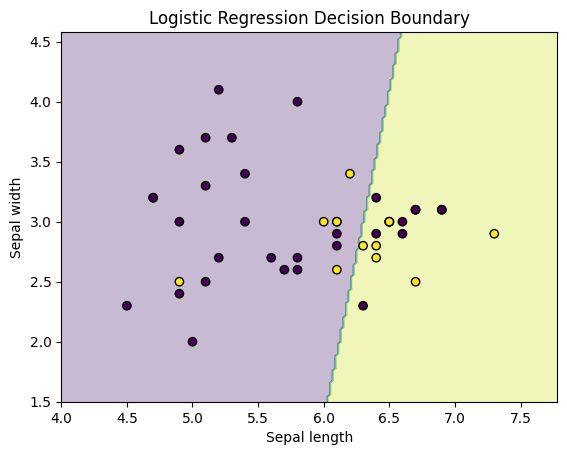

In [19]:
## decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('Logistic Regression Decision Boundary')
    plt.show()

plot_decision_boundary(X_test, y_test, model)

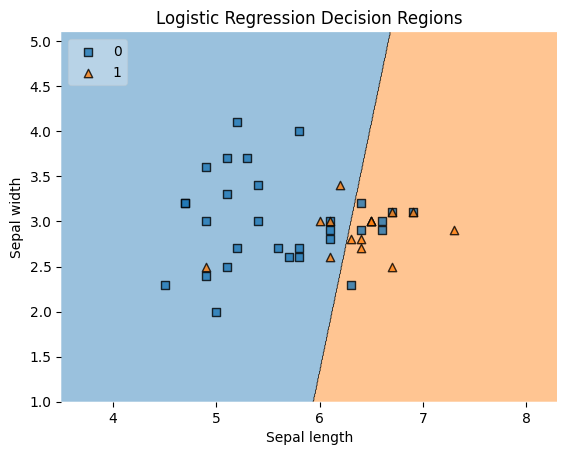

In [21]:
from mlxtend.plotting import plot_decision_regions
def plot_decision_boundary_mlxtend(X, y, model):
    plot_decision_regions(X=X, y=y.astype(int), clf=model, legend=2)

    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('Logistic Regression Decision Regions')
    plt.show()

plot_decision_boundary_mlxtend(X_test, y_test, model)

In [22]:
## Let's try on multi class
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, label_binarize 
## Label binarize: It is mostly used when you have multi-class classification and you want to convert your labels into a one-hot encoded format.
from sklearn.metrics import roc_auc_score, roc_curve


In [26]:
wine = load_wine()
X,y = wine.data, wine.target
## split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3,random_state= 42)


In [27]:
from sklearn.pipeline import Pipeline
Pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(multi_class= 'multinomial', solver='lbfgs', max_iter=1000,random_state= 42))
])
Pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    random_state=42))])

In [32]:
y_pred = Pipe.predict(X_test)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score =   Pipe.predict_proba(X_test)
print(accuracy_score(y_pred, y_test))

0.9814814814814815


In [ ]:
iris = load_iris()
X = iris.data[:, :2] ##using only 2 features
y = (iris.target == 2).astype(int) ## using only 1 class 

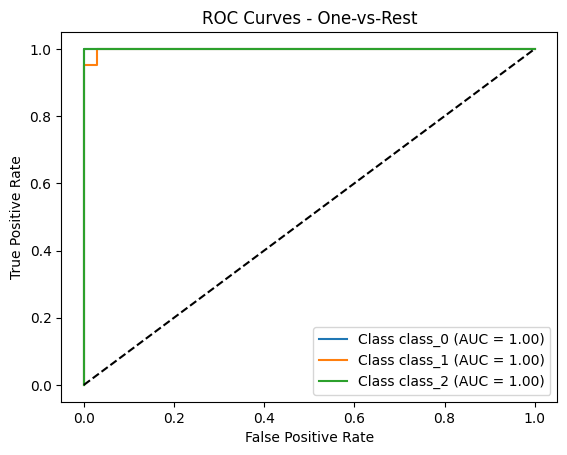

In [29]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {wine.target_names[i]} (AUC = {auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - One-vs-Rest')
plt.legend()
plt.show()